# Notebook 04: Pipeline Output Overview (Week 2 Handover)

**Purpose**: This notebook is the teammate-facing walkthrough of the Week 2 deliverable. It shows you how to load the per-firm Gaussian Mixture Model parameters and the pairwise Bhattacharyya Coefficient (BC) matrix, how to compute BC between two firms by hand so you can trust the matrix values, how to find the top-k most-similar firms for any target firm, and what caveats are still in progress.

The production dataset covers **7,485 deduplicated firms** in the technology and biotech sectors, fitted at **K_max=15** (the production lock; see ADR-004). The BC matrix uses the **linear-weighted formula** (bounded in [0, 1]; see the correctness note in Section 3).

Plan on 4-6 hours to work through this notebook — Sections 3-4 are where the practical feel for the BC matrix comes from, and Section 7's caveats table is what you need before framing any regression.


## Section 1: Setup — placing the handoff bundle

You should have received an artifact bundle from Torrin (email attachment or shared link). It contains 8 files plus `SHA256SUMS.txt`. Extract it and place the files as follows, from the repository root:

**Into `output/kmax_sweep/corrected/output/kmax_sweep/`** (the nested path is intentional — it's the S3-sync layout; we document rather than flatten it):

- `firm_gmm_parameters_k15.parquet` — primary per-firm GMM parameters (K_max=15)
- `bc_matrix_all_k15_dedup_linear.npz` — primary pairwise BC matrix at K=15
- `firm_gmm_parameters_k10.parquet` — convergence-floor reference (K_max=10)
- `bc_matrix_all_k10_dedup_linear.npz` — reference BC matrix at K=10

**Into `output/kmax_sweep/`:**

- `deduplication_decisions.csv` — audit trail for 464 firms removed
- `excluded_firms.csv` — firms removed for <5 patents
- `coassignment_audit.parquet` — top-100 BC pair shared-patent audit

**Verify transfer integrity** before running the notebook:

```bash
cd /path/to/extracted/bundle
sha256sum -c SHA256SUMS.txt
```

Then launch Jupyter from the repo root and run all cells.


In [1]:
# Imports and global plot style (matches Notebook 03's conventions)
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Auto-anchor to repo root so relative paths work whether you launch Jupyter
# from the repo root (recommended) or from notebooks/
if not Path("output/kmax_sweep").exists() and Path("../output/kmax_sweep").exists():
    os.chdir("..")
    print(f"Changed working directory to repo root: {os.getcwd()}")

# Artifact paths — the nested `corrected/output/kmax_sweep/` layout is a sync artifact
# from the 2026-04-12 S3 re-deploy; we document rather than flatten it.
CORRECTED = Path("output/kmax_sweep/corrected/output/kmax_sweep")
SWEEP = Path("output/kmax_sweep")

GMM_K15 = CORRECTED / "firm_gmm_parameters_k15.parquet"
BC_K15 = CORRECTED / "bc_matrix_all_k15_dedup_linear.npz"
GMM_K10 = CORRECTED / "firm_gmm_parameters_k10.parquet"
BC_K10 = CORRECTED / "bc_matrix_all_k10_dedup_linear.npz"
DEDUP_CSV = SWEEP / "deduplication_decisions.csv"
EXCLUDED_CSV = SWEEP / "excluded_firms.csv"
COASSIGN_PARQUET = SWEEP / "coassignment_audit.parquet"

# Fail early with a helpful message if teammates haven't placed the bundle files yet
for p in [GMM_K15, BC_K15, GMM_K10, BC_K10, DEDUP_CSV, EXCLUDED_CSV, COASSIGN_PARQUET]:
    assert p.exists(), f"Missing {p}. Did you place the bundle files per Section 1?"

print("All bundle files present. Ready to load.")


Changed working directory to repo root: /mnt/c/Users/TPata/firm-pair_merger_prediction
All bundle files present. Ready to load.


### Firm name mapping

We hardcode a small mapping from `gvkey` to firm name for the 5 deep-dive firms used in Notebook 03's convergence analysis. These are the only names we verify against the deduplicated gvkey set; teammates can extend the dict with other Compustat-verified gvkeys of economic interest (the top-15 firms by patent count are printed in Section 2 for reference).


In [2]:
# Verified against Notebook 03's DEEP_DIVE_FIRMS (all 5 present in the K=15
# deduplicated BC matrix). Extend with Compustat-verified gvkeys as needed;
# do not guess — unknown firms should remain as their gvkey.
FIRM_NAMES = {
    "006066": "IBM",
    "012141": "Intel",
    "024800": "Qualcomm",
    "160329": "Google / Alphabet",
    "020779": "Cisco Systems",
}


## Section 2: Loading the data

Two primary artifacts back every downstream analysis:

- **`firm_gmm_parameters_k15.parquet`** — one row per firm. Columns include `gvkey`, `n_patents`, `n_components` (the effective K after Dirichlet-process pruning), `tier` (`single_gaussian` or `gmm`), plus three binary blobs for means, covariances, and mixture weights. The deserializer below unpacks them.
- **`bc_matrix_all_k15_dedup_linear.npz`** — a dense 7485×7485 symmetric float64 matrix of pairwise BC values with diagonal = 1.0 (self-similarity).

Note: the GMM parquet contains **all 7,949 fitted firms** (pre-dedup), while the BC matrix covers only the **7,485 deduplicated firms**. We filter the GMM results to the BC matrix's `gvkeys` so indexing stays consistent.


In [3]:
def load_bc_matrix(path: Path) -> tuple[list[str], np.ndarray]:
    """Load a corrected BC matrix .npz archive.

    Returns (gvkeys, bc_matrix). The matrix is symmetric float64 with diagonal 1.0.
    """
    data = np.load(path, allow_pickle=True)
    gvkeys = [str(g) for g in data["gvkeys"]]
    bc_matrix = data["bc_matrix"]
    assert bc_matrix.shape == (len(gvkeys), len(gvkeys)), "gvkey/matrix shape mismatch"
    return gvkeys, bc_matrix


def load_gmm_results(path: Path) -> dict[str, dict]:
    """Load per-firm GMM parameters from parquet; return dict keyed by gvkey."""
    df = pd.read_parquet(path)
    d = 50  # UMAP output dimensionality
    lookup = {}
    for _, row in df.iterrows():
        k = int(row["n_components"])
        lookup[str(row["gvkey"])] = {
            "gvkey": str(row["gvkey"]),
            "n_patents": int(row["n_patents"]),
            "n_components": k,
            "tier": row["tier"],
            "means": np.frombuffer(row["means"], dtype=np.float64).reshape(k, d),
            "covariances": np.frombuffer(row["covariances"], dtype=np.float64).reshape(k, d),
            "weights": np.frombuffer(row["weights"], dtype=np.float64).reshape(k),
        }
    return lookup


gvkeys, bc_matrix = load_bc_matrix(BC_K15)
gvkey_to_idx = {gv: i for i, gv in enumerate(gvkeys)}
gmm_lookup = load_gmm_results(GMM_K15)

print(f"BC matrix: {bc_matrix.shape}, diagonal mean = {np.diag(bc_matrix).mean():.6f}")
print(f"GMM parameters: {len(gmm_lookup):,} firms pre-dedup")
print(f"Deduplicated set (BC matrix rows): {len(gvkeys):,} firms")


BC matrix: (7485, 7485), diagonal mean = 1.000000
GMM parameters: 7,949 firms pre-dedup
Deduplicated set (BC matrix rows): 7,485 firms


In [4]:
# Sanity checks — if any fail, the artifacts are corrupted or mismatched.
assert bc_matrix.shape[0] == bc_matrix.shape[1] == len(gvkeys), "BC matrix is not square"
assert np.allclose(bc_matrix, bc_matrix.T, atol=1e-12), "BC matrix is not symmetric"
assert np.allclose(np.diag(bc_matrix), 1.0, atol=1e-9), "BC diagonal is not all 1.0"
assert (bc_matrix >= 0).all() and (bc_matrix <= 1 + 1e-9).all(), "BC values outside [0, 1]"

# Every BC-matrix firm should have GMM parameters
missing = [gv for gv in gvkeys if gv not in gmm_lookup]
assert not missing, f"{len(missing)} firms in BC matrix but missing GMM params"
print("All sanity checks pass.")


All sanity checks pass.


### Summary statistics — effective K distribution and tier breakdown


In [5]:
# Summarize effective K for deduplicated firms only (BC matrix members)
dedup_gmm = pd.DataFrame(
    [{"gvkey": gv, "n_patents": gmm_lookup[gv]["n_patents"],
      "n_components": gmm_lookup[gv]["n_components"], "tier": gmm_lookup[gv]["tier"]}
     for gv in gvkeys]
)

print("Tier distribution (K=15 deduplicated):")
print(dedup_gmm["tier"].value_counts().to_string())

print("\nEffective K distribution:")
print(dedup_gmm["n_components"].value_counts().sort_index().to_string())

print("\nTop 15 firms by patent count (useful for identifying Compustat gvkeys):")
top_firms = dedup_gmm.nlargest(15, "n_patents")[["gvkey", "n_patents", "n_components", "tier"]]
top_firms["name"] = top_firms["gvkey"].map(FIRM_NAMES).fillna("(unknown — verify via Compustat)")
print(top_firms.to_string(index=False))


Tier distribution (K=15 deduplicated):
tier
single_gaussian    5979
gmm                1506

Effective K distribution:
n_components
1     5989
2       27
3       43
4       67
5       77
6       88
7      101
8       87
9      108
10     114
11     134
12     159
13     156
14     161
15     174

Top 15 firms by patent count (useful for identifying Compustat gvkeys):
 gvkey  n_patents  n_components tier                             name
006066     156616            15  gmm                              IBM
006008      50469            15  gmm (unknown — verify via Compustat)
012141      47223            15  gmm                            Intel
005606      39719            15  gmm (unknown — verify via Compustat)
007343      36127            15  gmm (unknown — verify via Compustat)
024800      35548            15  gmm                         Qualcomm
160329      29813            15  gmm                Google / Alphabet
001690      29381            15  gmm (unknown — verify via Compustat)


## Section 3: Worked example — IBM vs Intel

This section computes the BC between IBM (gvkey 006066) and Intel (gvkey 012141) two ways — by matrix lookup and by re-deriving the formula from their GMM parameters — and asserts they match to float64 tolerance. If this assertion fails, either the matrix is the old (buggy) √-weighted variant or the formula has been modified; see the correctness note below.

**Correctness note**. The BC formula uses **linear** mixing weights πᵢπⱼ, not the √-weighted variant `√(πᵢ·πⱼ)`. The √-weighted variant is mathematically an upper bound that exceeds 1.0 for multi-component mixtures (observed up to 5.39 in an earlier iteration of the sweep), and it was the root cause of the original K_max=15→20 ranking instability we caught during the 2026-04-12 correction. The corrected linear formula is bounded in [0, 1] by Cauchy-Schwarz, and it is the production formula throughout this notebook and the shipped BC matrix.


In [6]:
def bc_component_matrix(mu_a: np.ndarray, var_a: np.ndarray,
                       mu_b: np.ndarray, var_b: np.ndarray) -> np.ndarray:
    """BC between all component pairs of two GMMs (diagonal covariance, vectorized).

    Closed form under diagonal covariance (ADR-006):
        D_B = (1/8) Σ_d (μᵢ_d - μⱼ_d)² / σ̄²_d
            + (1/2) Σ_d ln(σ̄²_d / √(σ²ᵢ_d · σ²ⱼ_d))
        BC  = exp(-D_B)
    where σ̄²_d = (σ²ᵢ_d + σ²ⱼ_d) / 2.

    Returns (K_A, K_B) float64 matrix of component-pair BC values in [0, 1].
    """
    sigma_avg = (var_a[:, None, :] + var_b[None, :, :]) / 2.0   # (K_A, K_B, D)
    diff = mu_a[:, None, :] - mu_b[None, :, :]                  # (K_A, K_B, D)
    mahal = 0.125 * np.sum(diff**2 / sigma_avg, axis=2)         # (K_A, K_B)
    log_det_avg = np.sum(np.log(sigma_avg), axis=2)             # (K_A, K_B)
    log_det_a = np.sum(np.log(var_a), axis=1)                   # (K_A,)
    log_det_b = np.sum(np.log(var_b), axis=1)                   # (K_B,)
    det_term = 0.5 * (log_det_avg - 0.5 * (log_det_a[:, None] + log_det_b[None, :]))
    return np.exp(-(mahal + det_term))


def bc_mixture_linear(gmm_a: dict, gmm_b: dict) -> float:
    """Mixture-level BC with linear πᵢπⱼ weights (bounded in [0, 1]).

        BC(A, B) = Σᵢ Σⱼ πᵢᴬ · πⱼᴮ · BC(Nᵢᴬ, Nⱼᴮ)

    Do NOT use √(πᵢπⱼ) — that is an upper bound that can exceed 1 for multi-
    component mixtures and caused the original K_max top-tail instability bug.
    """
    bc_grid = bc_component_matrix(
        gmm_a["means"], gmm_a["covariances"],
        gmm_b["means"], gmm_b["covariances"],
    )
    weight_grid = gmm_a["weights"][:, None] * gmm_b["weights"][None, :]
    return float(np.sum(weight_grid * bc_grid))


In [7]:
# Compare IBM and Intel two ways: matrix lookup vs formula recomputation
gv_ibm, gv_intel = "006066", "012141"
i_ibm, i_intel = gvkey_to_idx[gv_ibm], gvkey_to_idx[gv_intel]

bc_from_matrix = float(bc_matrix[i_ibm, i_intel])
bc_from_formula = bc_mixture_linear(gmm_lookup[gv_ibm], gmm_lookup[gv_intel])

print(f"BC(IBM, Intel) via matrix lookup   = {bc_from_matrix:.12f}")
print(f"BC(IBM, Intel) via formula         = {bc_from_formula:.12f}")
print(f"Absolute difference                = {abs(bc_from_matrix - bc_from_formula):.2e}")

# This assertion is the notebook's reproducibility anchor. If it ever fails,
# the matrix and the formula have drifted out of agreement — do not trust
# downstream analysis until the discrepancy is resolved.
assert abs(bc_from_matrix - bc_from_formula) < 1e-9, \
    "Matrix lookup disagrees with formula recomputation — investigate!"
print("\nReproducibility anchor: matrix == formula (within float64 tolerance).")


BC(IBM, Intel) via matrix lookup   = 0.003392541515
BC(IBM, Intel) via formula         = 0.003392541515
Absolute difference                = 0.00e+00

Reproducibility anchor: matrix == formula (within float64 tolerance).


## Section 4: Top-k partners for a given firm

The most common downstream operation is "for firm X, who are its top-k most technologically similar firms?". The helper below returns a ranked DataFrame with partner gvkey, known name (or the gvkey itself if unknown), BC value, effective K, and patent count.

Heads-up on naming: private firms in Compustat have synthetic gvkeys prefixed `PRIV_` (e.g., `PRIV_ENDOLOGIX`). They are legitimate firms, not dedup leaks. The dedup rule (containment ≥ 0.95) was applied, and 464 aliases/subsidiaries/predecessors were already removed; see `deduplication_decisions.csv` for the audit trail.


In [8]:
def top_k_partners(query_gvkey: str, k: int = 20) -> pd.DataFrame:
    """Return the top-k firms most similar to query_gvkey by BC value."""
    if query_gvkey not in gvkey_to_idx:
        raise KeyError(
            f"{query_gvkey} is not in the 7,485-firm deduplicated set. "
            "Check deduplication_decisions.csv or excluded_firms.csv."
        )
    idx = gvkey_to_idx[query_gvkey]
    row = bc_matrix[idx].copy()
    row[idx] = -np.inf  # exclude self
    top_idx = np.argpartition(-row, k)[:k]
    top_idx = top_idx[np.argsort(-row[top_idx])]
    records = []
    for rank, j in enumerate(top_idx, start=1):
        partner = gvkeys[j]
        gmm = gmm_lookup.get(partner, {})
        records.append({
            "rank": rank,
            "gvkey": partner,
            "name": FIRM_NAMES.get(partner, partner),
            "bc": float(row[j]),
            "effective_k": gmm.get("n_components"),
            "n_patents": gmm.get("n_patents"),
        })
    return pd.DataFrame(records)


print("=== Top-20 partners for IBM (gvkey 006066) ===")
print(top_k_partners("006066", k=20).to_string(index=False))


=== Top-20 partners for IBM (gvkey 006066) ===
 rank                     gvkey                      name       bc  effective_k  n_patents
    1      PRIV_LANDESKSOFTWARE      PRIV_LANDESKSOFTWARE 0.013806            1         19
    2                  PRIV_IMT                  PRIV_IMT 0.010844            1          7
    3       PRIV_WESTPUBLISHING       PRIV_WESTPUBLISHING 0.010503            1         10
    4                    012136                    012136 0.009230           14       7254
    5                PRIV_QBASE                PRIV_QBASE 0.008731            1         33
    6                    012142                    012142 0.008729           15      11955
    7                    001690                    001690 0.007883           15      29381
    8                    006008                    006008 0.007731           15      50469
    9     PRIV_BASICELECTRONICS     PRIV_BASICELECTRONICS 0.007695            1          8
   10                   PRIV_C3            

In [9]:
print("=== Top-20 partners for Google / Alphabet (gvkey 160329) ===")
print(top_k_partners("160329", k=20).to_string(index=False))


=== Top-20 partners for Google / Alphabet (gvkey 160329) ===
 rank                         gvkey                          name       bc  effective_k  n_patents
    1                 PRIV_STOREDIQ                 PRIV_STOREDIQ 0.015127            1         13
    2                        062634                        062634 0.014826           13       2255
    3             PRIV_MDTECHNOLOGY             PRIV_MDTECHNOLOGY 0.013080            1         34
    4           PRIV_ROCKETSOFTWARE           PRIV_ROCKETSOFTWARE 0.013073            1         12
    5                        170617                        170617 0.012638           14       8477
    6 PRIV_PRECISESOFTWARESOLUTIONS PRIV_PRECISESOFTWARESOLUTIONS 0.012464            1         20
    7                        061694                        061694 0.011555            1         11
    8                        065466                        065466 0.010274            1          9
    9                        012141             

## Section 5: Distribution and sanity plots

Three quick visualizations ground our intuition for what the BC matrix looks like globally: the distribution of BC values across all off-diagonal pairs, the relationship between BC and firm-size product, and the effective-K distribution by tier.


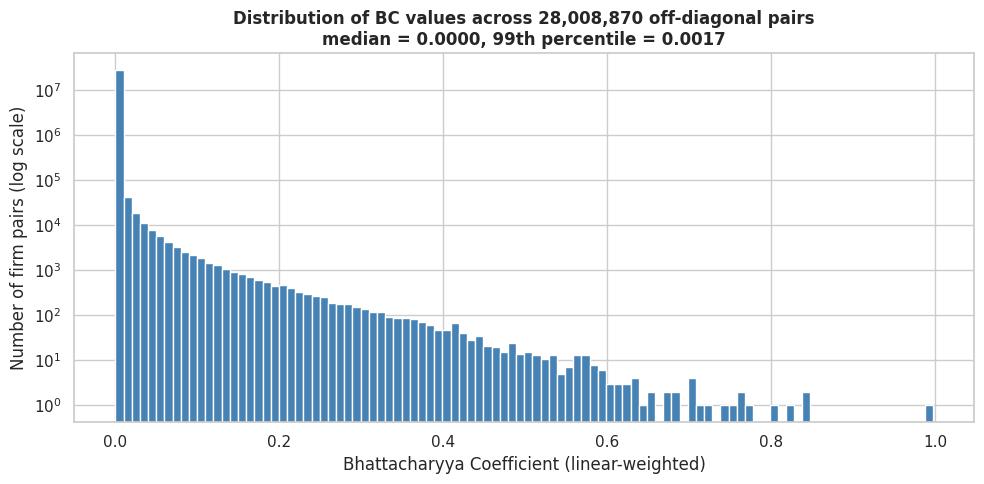

In [10]:
# Plot 1: BC value distribution (off-diagonal upper triangle, log y-axis)
iu = np.triu_indices(len(gvkeys), k=1)
off_diag_bc = bc_matrix[iu]

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(off_diag_bc, bins=100, color="steelblue", edgecolor="white")
ax.set_yscale("log")
ax.set_xlabel("Bhattacharyya Coefficient (linear-weighted)")
ax.set_ylabel("Number of firm pairs (log scale)")
ax.set_title(
    f"Distribution of BC values across {len(off_diag_bc):,} off-diagonal pairs\n"
    f"median = {np.median(off_diag_bc):.4f}, 99th percentile = {np.quantile(off_diag_bc, 0.99):.4f}",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


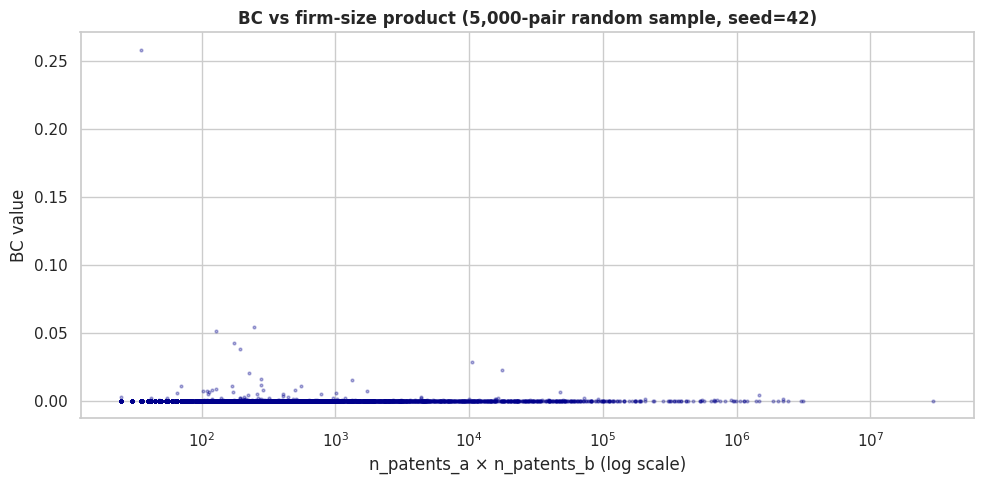

In [11]:
# Plot 2: BC vs firm-size-product (5,000-pair random sample for readability)
rng = np.random.default_rng(42)
sample_size = 5000
sample_i = rng.integers(0, len(gvkeys), size=sample_size)
sample_j = rng.integers(0, len(gvkeys), size=sample_size)
mask = sample_i != sample_j
sample_i, sample_j = sample_i[mask], sample_j[mask]
n_patents_arr = np.array([gmm_lookup[gv]["n_patents"] for gv in gvkeys])
size_product = n_patents_arr[sample_i] * n_patents_arr[sample_j]
bc_sample = bc_matrix[sample_i, sample_j]

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(size_product, bc_sample, s=4, alpha=0.3, color="darkblue")
ax.set_xscale("log")
ax.set_xlabel("n_patents_a × n_patents_b (log scale)")
ax.set_ylabel("BC value")
ax.set_title(
    f"BC vs firm-size product ({len(bc_sample):,}-pair random sample, seed=42)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()


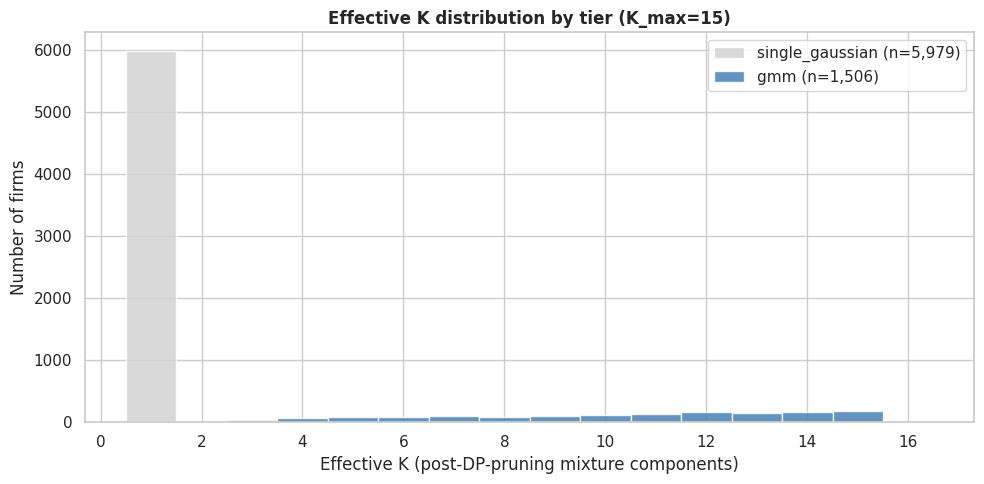

In [12]:
# Plot 3: Effective K distribution by tier
fig, ax = plt.subplots(figsize=(10, 5))
for tier, color in [("single_gaussian", "lightgray"), ("gmm", "steelblue")]:
    subset = dedup_gmm[dedup_gmm["tier"] == tier]["n_components"]
    ax.hist(subset, bins=np.arange(0.5, 17.5, 1.0), label=f"{tier} (n={len(subset):,})",
            color=color, edgecolor="white", alpha=0.85)
ax.set_xlabel("Effective K (post-DP-pruning mixture components)")
ax.set_ylabel("Number of firms")
ax.set_title("Effective K distribution by tier (K_max=15)", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


## Section 6: Co-assignment caveat (important for regression design)

A firm pair can have high BC for two reasons: (a) their patent portfolios genuinely occupy similar technological regions (the signal we want), or (b) they share a lot of patents already — joint ventures, subsidiaries missed by our containment-based dedup, or long-running collaborations. We ran a co-assignment audit on the top-100 BC pairs to quantify how much of (b) is in there. The parquet `output/kmax_sweep/coassignment_audit.parquet` has the full per-pair breakdown; aggregate stats follow.


In [13]:
audit = pd.read_parquet(COASSIGN_PARQUET)
assert len(audit) == 100, f"Expected 100 rows, got {len(audit)}"

median_shared = int(audit["n_shared"].median())
mean_jaccard = float(audit["jaccard"].mean())
n_ge10 = int((audit["overlap_fraction"] > 0.10).sum())
n_ge25 = int((audit["overlap_fraction"] > 0.25).sum())
n_zero = int((audit["n_shared"] == 0).sum())

print("Top-100 BC pair co-assignment audit (K_max=15, linear-weighted):")
print(f"  Median shared patent count: {median_shared}")
print(f"  Mean Jaccard similarity:    {mean_jaccard:.4f}")
print(f"  Pairs with >10% overlap:    {n_ge10} / 100")
print(f"  Pairs with >25% overlap:    {n_ge25} / 100")
print(f"  Pairs with 0 shared patents: {n_zero} / 100")

print("\nTop 5 pairs by overlap_fraction (candidate dedup misses to eyeball):")
print(audit.nlargest(5, "overlap_fraction")[
    ["rank", "gvkey_a", "gvkey_b", "bc", "n_shared", "overlap_fraction"]
].to_string(index=False))


Top-100 BC pair co-assignment audit (K_max=15, linear-weighted):
  Median shared patent count: 0
  Mean Jaccard similarity:    0.0135
  Pairs with >10% overlap:    2 / 100
  Pairs with >25% overlap:    2 / 100
  Pairs with 0 shared patents: 98 / 100

Top 5 pairs by overlap_fraction (candidate dedup misses to eyeball):
 rank                       gvkey_a                gvkey_b       bc  n_shared  overlap_fraction
   37                        060888  PRIV_OBLONGINDUSTRIES 0.595431        48          0.941176
   20                        063083         PRIV_ENDOLOGIX 0.668628        62          0.746988
    1 PRIV_AUTOMARKTECHNICALSYSTEMS    PRIV_EVERYONECOUNTS 0.997197         0          0.000000
    2                        289735 PRIV_ALTIOSTARNETWORKS 0.846398         0          0.000000
    3     PRIV_ALLERGYRESEARCHGROUP             PRIV_AVMAX 0.844774         0          0.000000


### Interpretation

**The dedup rule worked well.** Of the top-100 BC pairs, **98 share zero patents** and only **2 exceed 10% overlap**. Mean Jaccard is 0.014 — essentially zero. BC is substantially independent of co-assignment structure for the top-tier pairs; the signal is genuinely distributional rather than structural.

**Two outliers are worth flagging by name.** Rank 37 (`060888` + `PRIV_OBLONGINDUSTRIES`, 94% overlap) and rank 20 (`063083` + `PRIV_ENDOLOGIX`, 75% overlap) appear to be parent-subsidiary relationships that fell just below the 0.95 containment threshold. If your regressions rank top-20 or top-50 partners per firm, you will encounter these; treat them as known dedup misses rather than genuine tech-neighbour findings.

**Recommendation for regressions.** Include `n_shared` (or `jaccard`) from the audit parquet as a control covariate when running BC-based predictors. The effect size should be small given the audit numbers, but it is defensive against the 2 outliers and against the long tail of <top-100 pairs we did not audit.


## Section 7: Known caveats and open items

The dataset is ready for economic analysis. Several methodology and engineering items remain open and are shipped as promises, not finished work. The caveats table is honest about what has been checked and what is still in progress; the team email and README mirror it.

| Item | Status | Expected delivery |
|---|---|---|
| K_max=15 production lock | ✓ Done (ADR-004, 2026-04-14) | — |
| Deduplication (containment ≥ 0.95) | ✓ Done (464 firms removed; see `deduplication_decisions.csv`) | — |
| Linear-weighted BC formula | ✓ Done (corrected from √-weighted variant, 2026-04-12) | — |
| Convergence sweep (K_max ∈ {10,15,20,25,30}) | ✓ Done (Spearman ρ=0.991-0.993, top-50 overlap 96-100%; see Notebook 03) | — |
| Co-assignment audit (top-100) | ✓ Done (this notebook, Section 6) | — |
| BC spec (Codex review) | Reviewed; revisions in progress; **not yet approved for implementation** | Week 1 |
| BC module TDD (`src/comparison/bhattacharyya.py`) | Not started — production logic lives in `scripts/recompute_bc_corrected.py` | Week 2 |
| PortfolioBuilder / GMMFitter TDD (`src/portfolio/`) | Not started — production logic in `scripts/run_kmax_sweep.py` | Week 2-3 |
| Pruning-threshold audit | Not started | Week 1-2 |
| Gaussian adequacy audit | Not started | Week 1-2 |
| Directional complementarity (ADR-008 → v2 dataset) | Not started | Week 2-4 |
| Hyperparameter sensitivity (γ, κ₀, ν₀) | Contingent on Gaussian adequacy passing | Week 3-4 |

**Weeks are measured from 2026-04-15.** Each open item has its own acceptance criteria which will be posted as we go; ask in your regression work if any of these are blocking you and we can re-prioritize.


## Section 8: Where to find things

**In this repository:**

- `src/config/config.yaml` — all pipeline hyperparameters (K_max, prior, covariance type, etc.)
- `docs/adr/` — architecture decision records, especially:
  - `adr_004_k_selection_method.md` — K_max=15 production lock rationale
  - `adr_005_bayesian_prior_global_empirical.md` — prior choice
  - `adr_006_diagonal_covariance.md` — covariance structure
  - `adr_007_normalization.md` — normalization decision
- `docs/specs/firm_portfolio_spec.md` — GMM fitting contract
- `docs/specs/comparison_spec.md` — BC module spec (reviewed; revisions in progress)
- `docs/epics/week2_firm_portfolios/kmax_sweep_executive_summary.md` — decision narrative
- `docs/epics/week2_firm_portfolios/coassignment_audit_summary.md` — Section 6 summary
- `notebooks/03_kmax_convergence_analysis.ipynb` — full convergence story (run before this one if you want the methodology defense)
- `scripts/recompute_bc_corrected.py` — production source for the linear-weighted BC formula
- `scripts/coassignment_audit.py` — Section 6 audit source (re-runnable)

**Outside the repo:**

- Raw PatentSBERTa embeddings live on S3 at `s3://ubc-torrin/firm-pair-merger/runs/20260408T005013Z/output/embeddings/` — contact Torrin for access.
- Corrected sweep outputs (what's in your bundle) live at `s3://ubc-torrin/firm-pair-merger/week2/kmax_sweep/runs/20260412T043407Z-dedup-linear/`.

**When you hit a wall**: contact Torrin directly. For methodology questions not covered by the ADRs or specs, flag them and they'll become new ADRs.
